In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# TensorFlow & VGG16 for Feature Extraction
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

# Scikit-Learn Models & XGBoost
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [2]:
BASE_DIR = r"F:\CSE445 Project\data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Function to load dataset without shuffling so labels align perfectly for Scikit-Learn
def load_data(folder_name):
    dir_path = os.path.join(BASE_DIR, folder_name)
    return image_dataset_from_directory(
        dir_path,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=False 
    )

print("Loading datasets from F:\CSE445 Project\data ...")
train_ds = load_data('train')
val_ds = load_data('val')
test_ds = load_data('test')

# Extract exact integer labels to use for Scikit-Learn training
y_train = np.concatenate([y for x, y in train_ds], axis=0)
y_val = np.concatenate([y for x, y in val_ds], axis=0)
y_test = np.concatenate([y for x, y in test_ds], axis=0)

# Get class names for later
class_names = train_ds.class_names
print(f"Classes found: {class_names}")

Loading datasets from F:\CSE445 Project\data ...
Found 350 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Found 75 files belonging to 5 classes.
Classes found: ['cat', 'cow', 'dog', 'lamb', 'zebra']


In [3]:
# Load VGG16 without the final classification layer (include_top=False)
# pooling='avg' flattens the output into a neat 512-dimensional vector per image.
vgg_feature_extractor = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3), pooling='avg')

def extract_features(dataset):
    features = []
    for images, labels in dataset:
        # Preprocess images to match VGG16's specific formatting requirements
        preprocessed_images = preprocess_input(images)
        # Extract features
        extracted = vgg_feature_extractor.predict(preprocessed_images, verbose=0)
        features.append(extracted)
    return np.vstack(features)

print("Extracting features from Train set...")
X_train = extract_features(train_ds)

print("Extracting features from Test set...")
X_test = extract_features(test_ds)

print(f"Feature extraction complete! Training features shape: {X_train.shape}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 70s 1us/step
Extracting features from Train set...
Extracting features from Test set...
Feature extraction complete! Training features shape: (350, 512)


In [4]:
# Dictionary housing all the models from directory
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Naive Bayes": GaussianNB(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN (5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF Kernel)": SVC(probability=True, kernel='rbf', random_state=42),
    "Ridge Classifier": RidgeClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
}

# Create a Hybrid Model (Voting Classifier) based on top performers
hybrid_estimators = [
    ('lr', models["Logistic Regression"]),
    ('rf', models["Random Forest"]),
    ('svm', models["SVM (RBF Kernel)"]),
    ('xgb', models["XGBoost"])
]
# 'soft' voting uses the predicted probabilities from each model to make a final decision
models["Hybrid Model (LR+RF+SVM+XGB)"] = VotingClassifier(estimators=hybrid_estimators, voting='soft')

In [5]:
results = []

print("Training and evaluating models on Test Data...\n")

for name, model in models.items():
    # Fit the model on the VGG16 extracted training features
    model.fit(X_train, y_train)
    
    # Predict on the unseen Test features
    y_pred = model.predict(X_test)
    
    # Calculate Accuracy
    acc = accuracy_score(y_test, y_pred)
    results.append({'Model': name, 'Test Accuracy': acc})
    print(f"✅ {name} finished. Test Accuracy: {acc * 100:.2f}%")

# Create a clean dataframe to view results sorted by accuracy
results_df = pd.DataFrame(results).sort_values(by='Test Accuracy', ascending=False)
display(results_df)

Training and evaluating models on Test Data...

✅ Logistic Regression finished. Test Accuracy: 97.33%
✅ Decision Tree finished. Test Accuracy: 76.00%
✅ Naive Bayes finished. Test Accuracy: 90.67%
✅ Random Forest finished. Test Accuracy: 97.33%
✅ KNN (5) finished. Test Accuracy: 98.67%
✅ SVM (RBF Kernel) finished. Test Accuracy: 98.67%
✅ Ridge Classifier finished. Test Accuracy: 89.33%


F:\CSE445 Project\my_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
F:\CSE445 Project\my_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:23:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ XGBoost finished. Test Accuracy: 97.33%


F:\CSE445 Project\my_env\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
F:\CSE445 Project\my_env\Lib\site-packages\xgboost\training.py:200: UserWarning: [01:23:02] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Hybrid Model (LR+RF+SVM+XGB) finished. Test Accuracy: 98.67%


,Model,Test Accuracy
4,KNN (5),0.986667
8,Hybrid Model (LR+RF+SVM+XGB),0.986667
5,SVM (RBF Kernel),0.986667
0,Logistic Regression,0.973333
3,Random Forest,0.973333
7,XGBoost,0.973333
2,Naive Bayes,0.906667
6,Ridge Classifier,0.893333
1,Decision Tree,0.760000


C:\Users\User\AppData\Local\Temp\ipykernel_20768\1132736361.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Test Accuracy', y='Model', data=results_df, palette='viridis')


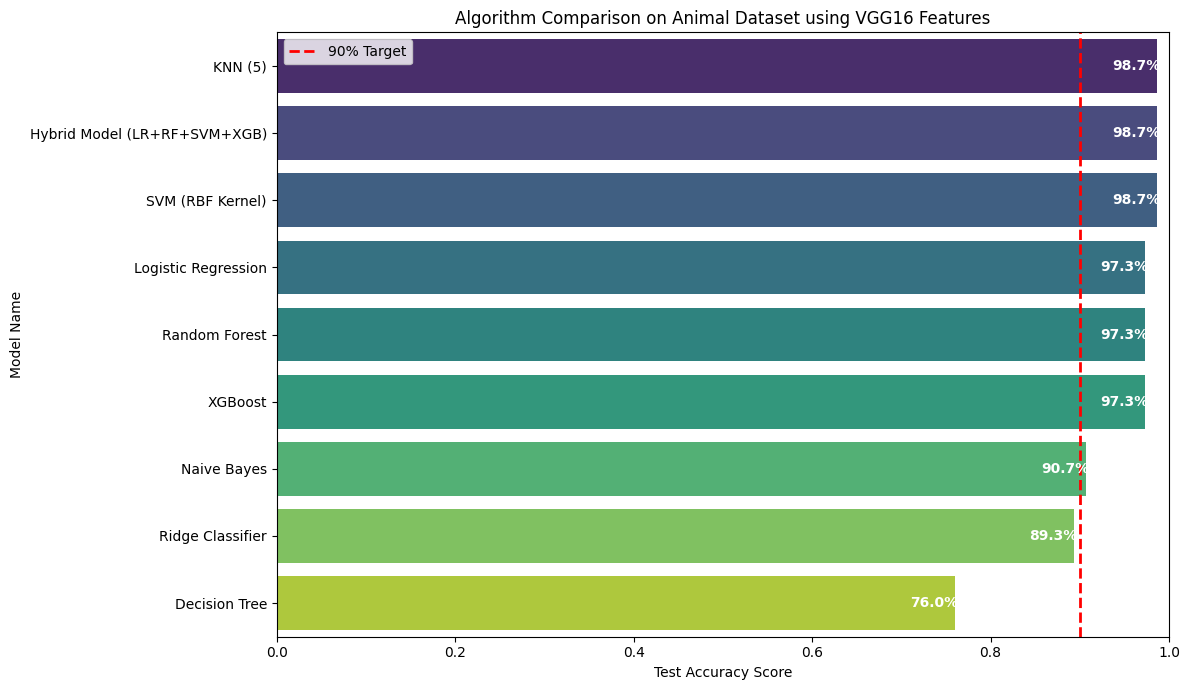

In [6]:
# Plotting the final results to see which model cleared the 90% target
plt.figure(figsize=(12, 7))
sns.barplot(x='Test Accuracy', y='Model', data=results_df, palette='viridis')
plt.title('Algorithm Comparison on Animal Dataset using VGG16 Features')
plt.xlabel('Test Accuracy Score')
plt.ylabel('Model Name')
plt.xlim(0, 1.0)

# Add a target line for 90% goal
plt.axvline(0.90, color='red', linestyle='--', linewidth=2, label='90% Target')

# Add accuracy text onto the bars
for index, value in enumerate(results_df['Test Accuracy']):
    plt.text(value - 0.05, index, f"{value*100:.1f}%", color='white', va='center', fontweight='bold')

plt.legend()
plt.tight_layout()
plt.show()

Calculating detailed evaluation metrics (Precision, Recall, F1-Score, AUC)...

--- Detailed Evaluation Metrics ---


,Precision,Recall,F1-Score,AUC Score
Model,,,,
Logistic Regression,0.9765,0.9733,0.9732,0.9998
Decision Tree,0.7683,0.7600,0.7625,0.8500
Naive Bayes,0.9275,0.9067,0.9090,NaN
Random Forest,0.9765,0.9733,0.9737,0.9991
KNN (5),0.9875,0.9867,0.9867,0.9928
SVM (RBF Kernel),0.9875,0.9867,0.9867,0.9996
Ridge Classifier,0.8940,0.8933,0.8917,NaN
XGBoost,0.9750,0.9733,0.9733,1.0000
Hybrid Model (LR+RF+SVM+XGB),0.9875,0.9867,0.9867,0.9998


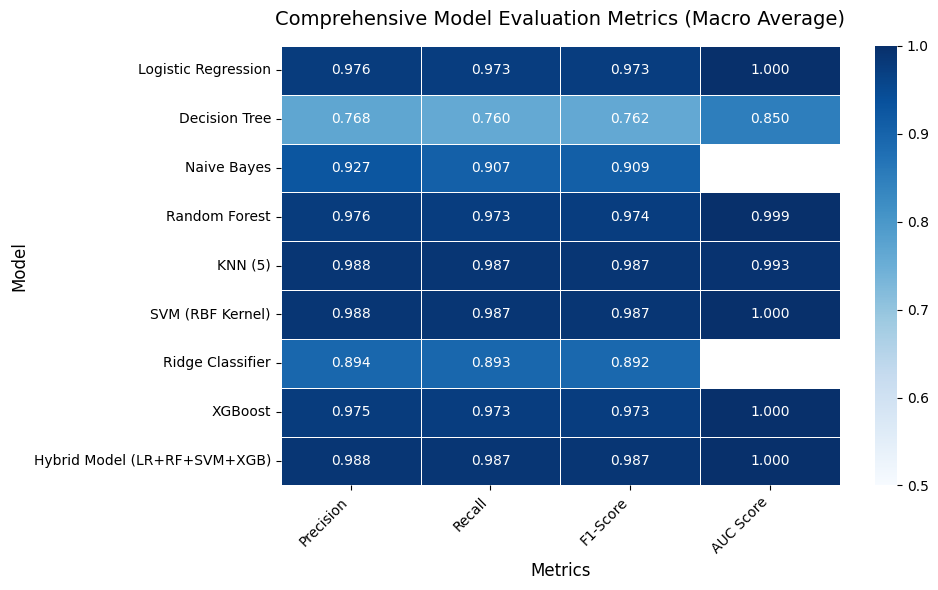

In [7]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd
import numpy as np

# Prepare a list to store all the detailed metrics
detailed_results = []

print("Calculating detailed evaluation metrics (Precision, Recall, F1-Score, AUC)...")

for name, model in models.items():
    # 1. Get standard predictions
    y_pred = model.predict(X_test)
    
    # 2. Calculate Precision, Recall, and F1 (Macro Average for multi-class)
    precision = precision_score(y_test, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
    
    # 3. Calculate Multi-Class AUC Score
    auc_score = np.nan # Default to NaN for models without predict_proba (like Ridge)
    
    if hasattr(model, "predict_proba"):
        try:
            # Predict probabilities for each class
            y_prob = model.predict_proba(X_test)
            # Calculate One-vs-Rest (OVR) multi-class AUC
            auc_score = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
        except Exception:
            pass # Failsafe if a model's predict_proba throws an unexpected error
            
    # Append to our results list
    detailed_results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC Score': auc_score
    })

# Convert results to a DataFrame and set the Model name as the index
metrics_df = pd.DataFrame(detailed_results).set_index('Model')

# Display the tabular results
print("\n--- Detailed Evaluation Metrics ---")
display(metrics_df.round(4))

# ---------------------------------------------------------
# VISUALIZATION: Heatmap of Metrics
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))

# We use a heatmap to easily spot which model performs best across all metrics
sns.heatmap(metrics_df, annot=True, cmap='Blues', fmt='.3f', linewidths=.5, vmin=0.5, vmax=1.0)

plt.title('Comprehensive Model Evaluation Metrics (Macro Average)', fontsize=14, pad=15)
plt.ylabel('Model', fontsize=12)
plt.xlabel('Metrics', fontsize=12)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Generating Confusion Matrices for all models...


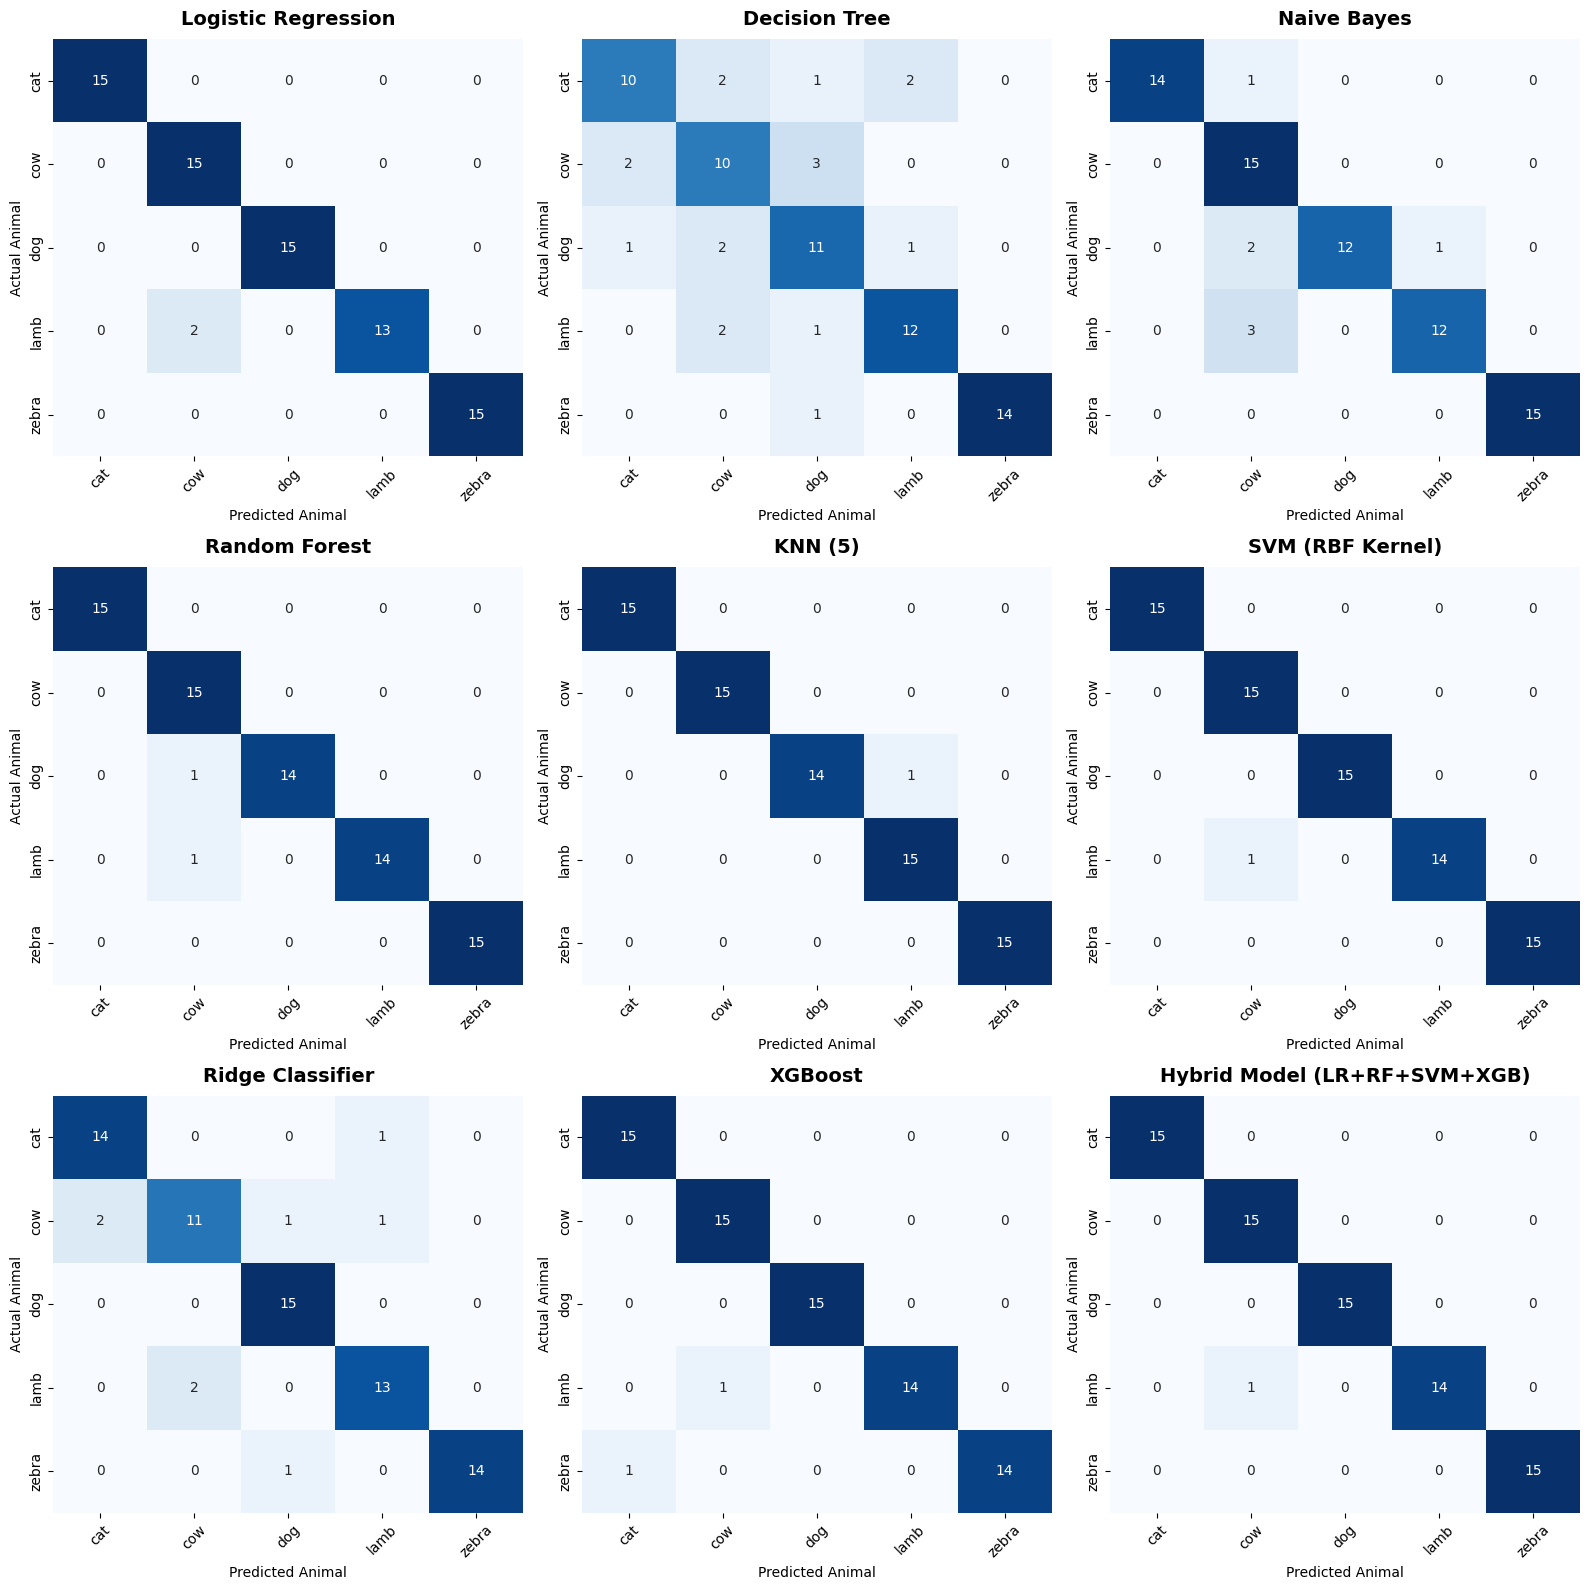

In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Confusion Matrices for all models...")

# Set up a 3x3 grid of subplots for our 9 models
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 16))
# Flatten the axes array to easily iterate over it
axes = axes.flatten()

# Iterate through each model and its corresponding subplot axis
for ax, (name, model) in zip(axes, models.items()):
    # Get predictions for the test set
    y_pred = model.predict(X_test)
    
    # Generate the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Plot the confusion matrix using Seaborn heatmap
    sns.heatmap(
        cm, 
        annot=True,       # Show the actual numbers in the cells
        fmt='d',          # Format as integers
        cmap='Blues',     # Use a blue color scale
        cbar=False,       # Hide the colorbar to save space
        ax=ax,            # Plot on the current subplot
        xticklabels=class_names, # Use actual animal names (from Cell 2)
        yticklabels=class_names
    )
    
    # Set titles and labels
    ax.set_title(name, fontsize=14, fontweight='bold', pad=10)
    ax.set_ylabel('Actual Animal', fontsize=10)
    ax.set_xlabel('Predicted Animal', fontsize=10)

    # Rotate x-axis labels so they don't overlap
    ax.tick_params(axis='x', rotation=45)

# Adjust layout so everything fits perfectly without overlapping
plt.tight_layout()
plt.show()

Generating Model Prediction Correlation Matrix...


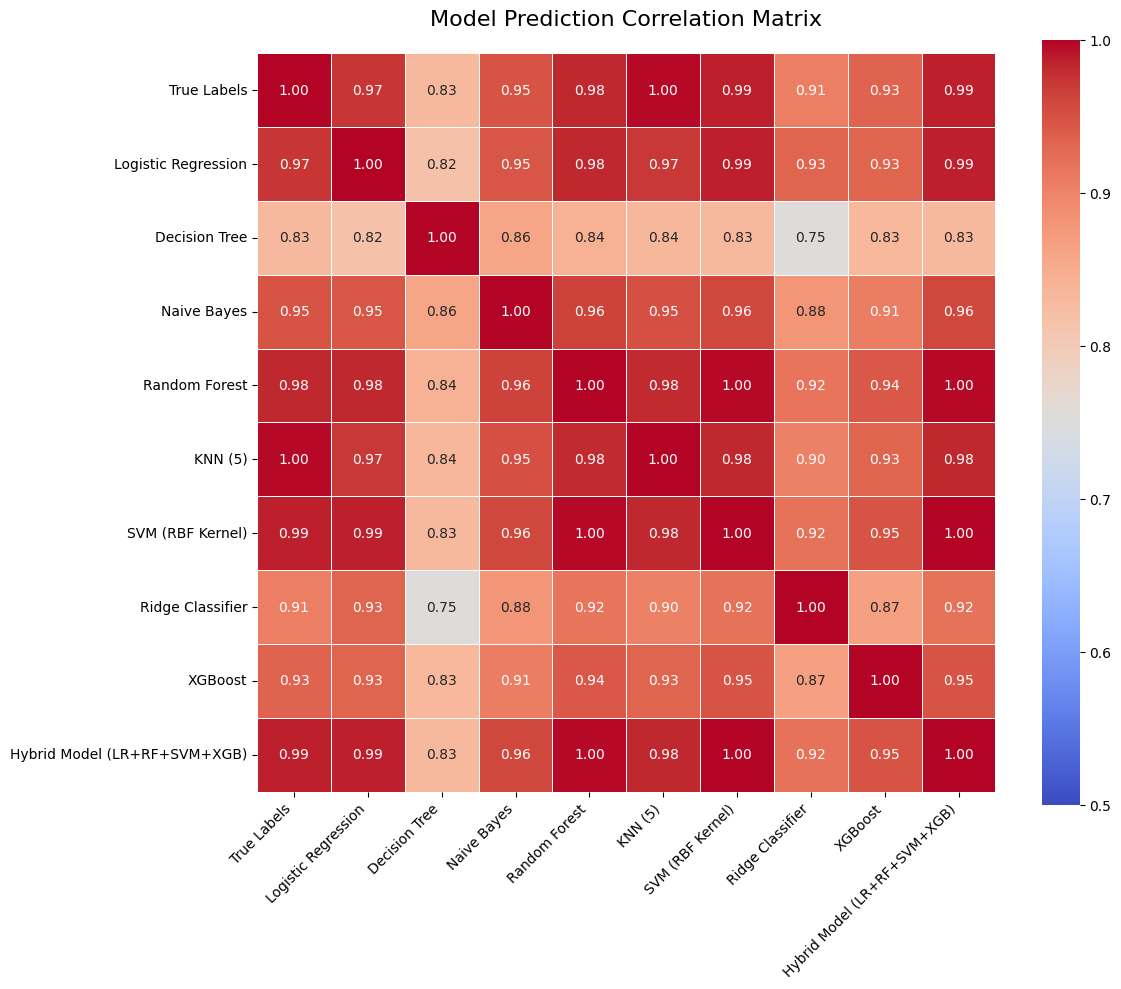

In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating Model Prediction Correlation Matrix...")

# 1. Create a dictionary to hold the predictions of every model
predictions_dict = {}

# Store the actual true labels as the first column for reference
predictions_dict['True Labels'] = y_test

# 2. Gather predictions from all models
for name, model in models.items():
    predictions_dict[name] = model.predict(X_test)

# 3. Convert the dictionary into a Pandas DataFrame
predictions_df = pd.DataFrame(predictions_dict)

# 4. Calculate the correlation matrix
# This calculates how heavily the predictions of one model align with another
correlation_matrix = predictions_df.corr()

# 5. Visualize the correlation matrix using a Seaborn heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix, 
    annot=True,          # Show the correlation coefficient numbers
    fmt='.2f',           # Format to 2 decimal places
    cmap='coolwarm',     # Red for high correlation, Blue for low
    vmin=0.5, vmax=1.0,  # Scale from 0.5 to 1.0 since models will generally agree
    linewidths=0.5,
    square=True
)

plt.title('Model Prediction Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Scanning original image dimensions in the training set...
Successfully processed 350 training images for dimension statistics.


C:\Users\User\AppData\Local\Temp\ipykernel_20768\3942326749.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_20768\3942326749.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


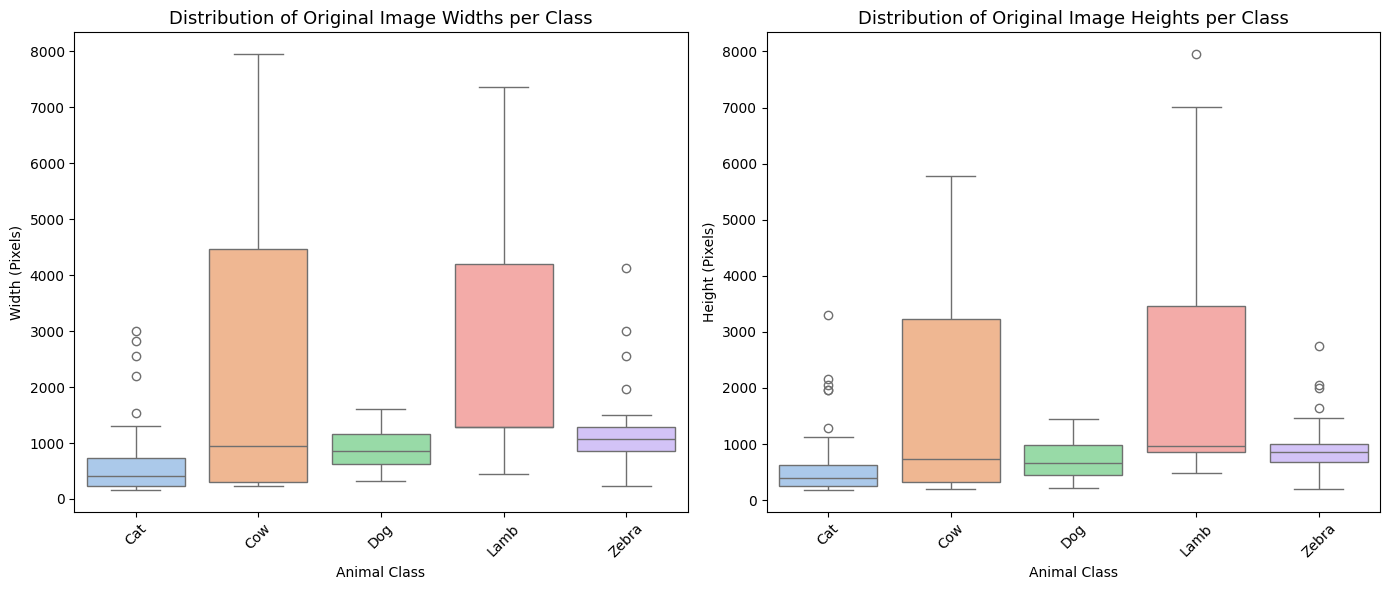

Width                                                        Height  \
      count    mean     std    min     25%     50%     75%     max  count   
Class                                                                       
Cat    70.0   599.5   601.1  163.0   223.5   411.5   735.0  3000.0   70.0   
Cow    70.0  2469.9  2373.7  229.0   300.0   945.5  4460.0  7952.0   70.0   
Dog    70.0   901.6   372.3  319.0   629.0   856.5  1170.0  1600.0   70.0   
Lamb   70.0  2511.3  1911.0  447.0  1280.0  1280.0  4199.0  7360.0   70.0   
Zebra  70.0  1112.1   576.6  240.0   853.0  1080.0  1280.0  4120.0   70.0   

                                                            
         mean     std    min    25%    50%     75%     max  
Class                                                       
Cat     568.8   560.2  183.0  259.0  389.0   633.0  3294.0  
Cow    1806.7  1707.4  200.0  318.8  725.0  3232.5  5773.0  
Dog     704.1   313.3  210.0  450.0  667.0   984.0  1440.0  
Lamb   2071.0  1670.9  492.0  853.0  965.5  3456.0  7952.0  
Zebra   887.7   414.3  194.0  676.8  852.5  1000.0  2747.0

In [10]:
import os
from PIL import Image
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Scanning original image dimensions in the training set...")

# Define the path to the training folder
TRAIN_DIR = os.path.join(BASE_DIR, 'train')

image_stats = []

# Loop through each animal folder inside the train directory
for class_name in class_names:
    class_dir = os.path.join(TRAIN_DIR, class_name)
    
    # Check if directory exists
    if os.path.isdir(class_dir):
        # Loop through all images in the folder
        for img_name in os.listdir(class_dir):
            img_path = os.path.join(class_dir, img_name)
            
            try:
                # Open the image just to read its size (metadata), doesn't load full pixel data
                with Image.open(img_path) as img:
                    width, height = img.size
                    image_stats.append({
                        'Class': class_name.capitalize(),
                        'Width': width,
                        'Height': height
                    })
            except Exception as e:
                # Silently skip any non-image files if they exist
                pass

# Convert to Pandas DataFrame
stats_df = pd.DataFrame(image_stats)

print(f"Successfully processed {len(stats_df)} training images for dimension statistics.")

# ---------------------------------------------------------
# VISUALIZATION: Box Plots for Widths and Heights
# ---------------------------------------------------------
# Set up a plot with 1 row and 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Boxplot for Image Widths
sns.boxplot(
    data=stats_df, 
    x='Class', 
    y='Width', 
    palette='pastel', 
    ax=axes[0]
)
axes[0].set_title('Distribution of Original Image Widths per Class', fontsize=13)
axes[0].set_ylabel('Width (Pixels)')
axes[0].set_xlabel('Animal Class')
axes[0].tick_params(axis='x', rotation=45)

# Boxplot for Image Heights
sns.boxplot(
    data=stats_df, 
    x='Class', 
    y='Height', 
    palette='pastel', 
    ax=axes[1]
)
axes[1].set_title('Distribution of Original Image Heights per Class', fontsize=13)
axes[1].set_ylabel('Height (Pixels)')
axes[1].set_xlabel('Animal Class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Display a quick summary table of the statistics
display(stats_df.groupby('Class').describe().round(1))

Generating Scatter Plot for Image Dimensions...


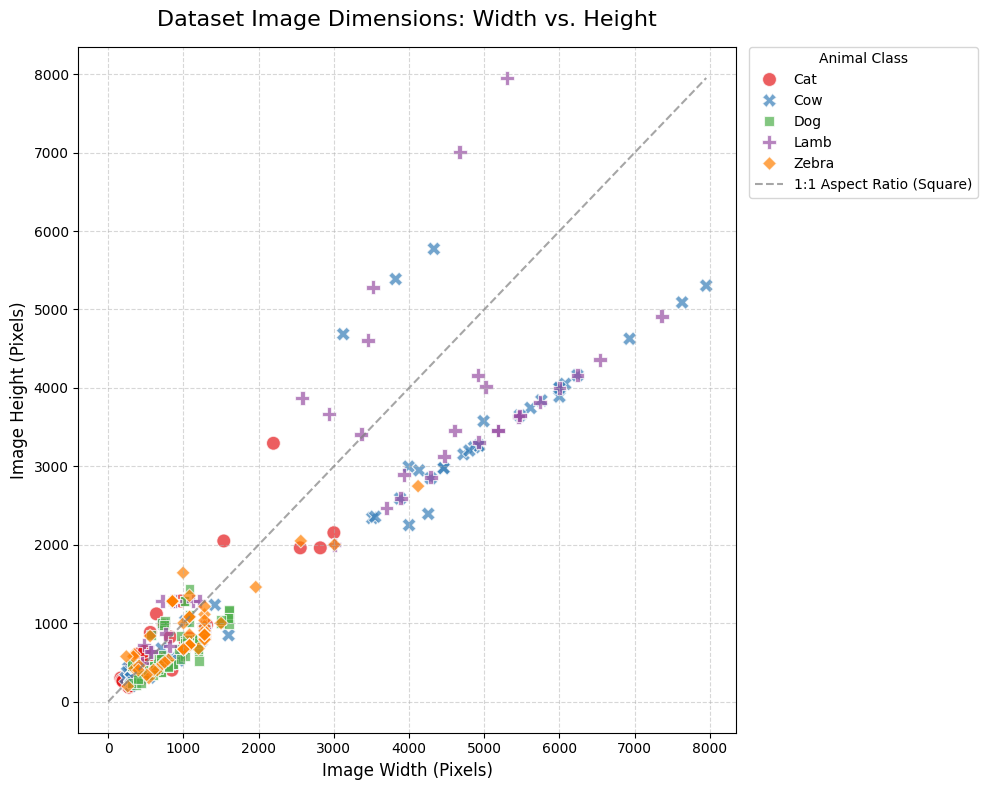

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating Scatter Plot for Image Dimensions...")

# We use the 'stats_df' created in the previous cell.


plt.figure(figsize=(10, 8))

# Create a scatter plot of Width vs Height, distinctly colored and styled by Class
sns.scatterplot(
    data=stats_df, 
    x='Width', 
    y='Height', 
    hue='Class',       # Different color for each animal
    style='Class',     # Different marker shape for each animal
    palette='Set1',    # Used a bright, distinct color palette
    s=100,             # Size of the markers
    alpha=0.7          # Slight transparency so overlapping points are visible
)

# Added a diagonal dashed line representing a 1:1 Aspect Ratio (perfect squares)
# This helps to see which images are landscape (below line) vs portrait (above line)
max_dim = max(stats_df['Width'].max(), stats_df['Height'].max())
plt.plot([0, max_dim], [0, max_dim], color='gray', linestyle='--', alpha=0.7, label='1:1 Aspect Ratio (Square)')

plt.title('Dataset Image Dimensions: Width vs. Height', fontsize=16, pad=15)
plt.xlabel('Image Width (Pixels)', fontsize=12)
plt.ylabel('Image Height (Pixels)', fontsize=12)

# Move the legend outside the plot so it doesn't cover your data points
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Animal Class', borderaxespad=0.)

# Add a subtle grid for readability
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Generating Histograms for Image Dimensions...


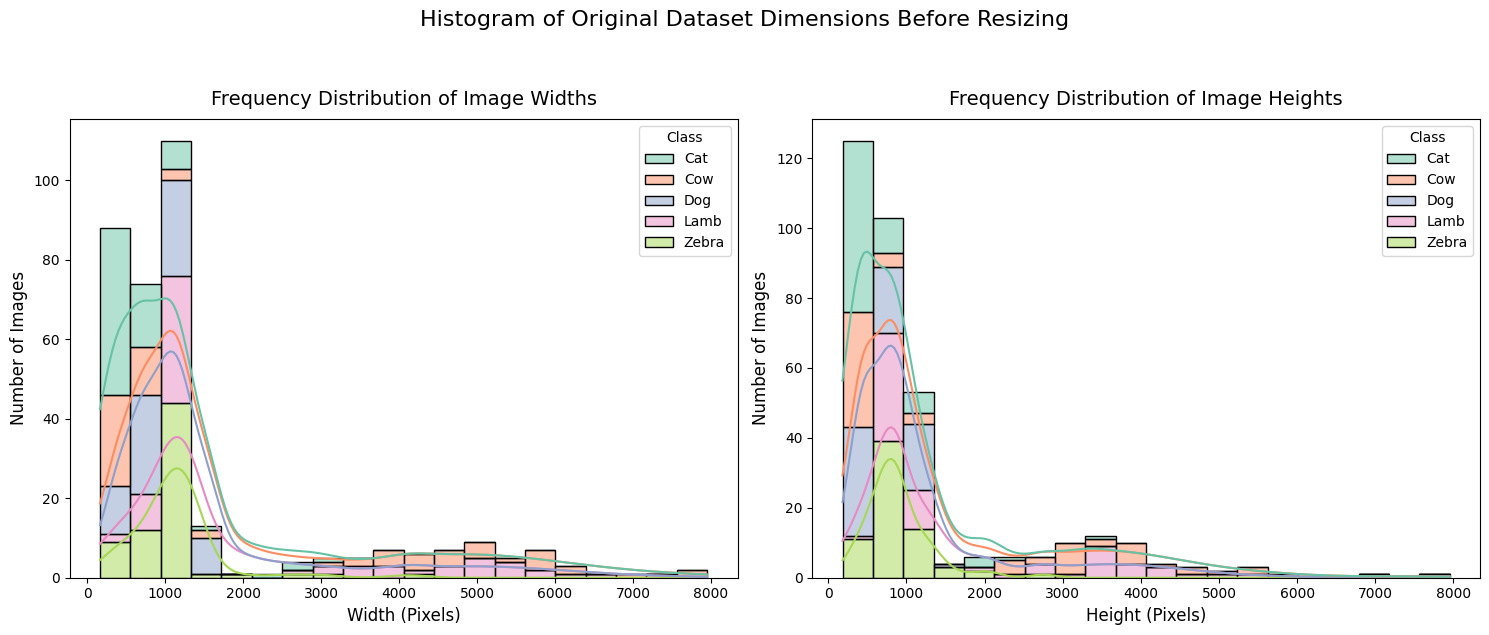

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

print("Generating Histograms for Image Dimensions...")

# Set up a plot with 1 row and 2 columns for side-by-side histograms
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# ---------------------------------------------------------
# Histogram 1: Image Widths
# ---------------------------------------------------------
sns.histplot(
    data=stats_df, 
    x='Width', 
    hue='Class',       # Color by animal class
    multiple='stack',  # Stack the bars on top of each other for total count
    kde=True,          # Added a Kernel Density Estimate (smooth curve)
    palette='Set2',
    bins=20,           # Group data into 20 bins
    ax=axes[0]
)
axes[0].set_title('Frequency Distribution of Image Widths', fontsize=14, pad=10)
axes[0].set_xlabel('Width (Pixels)', fontsize=12)
axes[0].set_ylabel('Number of Images', fontsize=12)

# ---------------------------------------------------------
# Histogram 2: Image Heights
# ---------------------------------------------------------
sns.histplot(
    data=stats_df, 
    x='Height', 
    hue='Class', 
    multiple='stack', 
    kde=True, 
    palette='Set2',
    bins=20, 
    ax=axes[1]
)
axes[1].set_title('Frequency Distribution of Image Heights', fontsize=14, pad=10)
axes[1].set_xlabel('Height (Pixels)', fontsize=12)
axes[1].set_ylabel('Number of Images', fontsize=12)

# Added an overarching title
plt.suptitle('Histogram of Original Dataset Dimensions Before Resizing', fontsize=16, y=1.05)

plt.tight_layout()
plt.show()

Generating Multi-Class ROC Curves (Macro-Average) for all models...


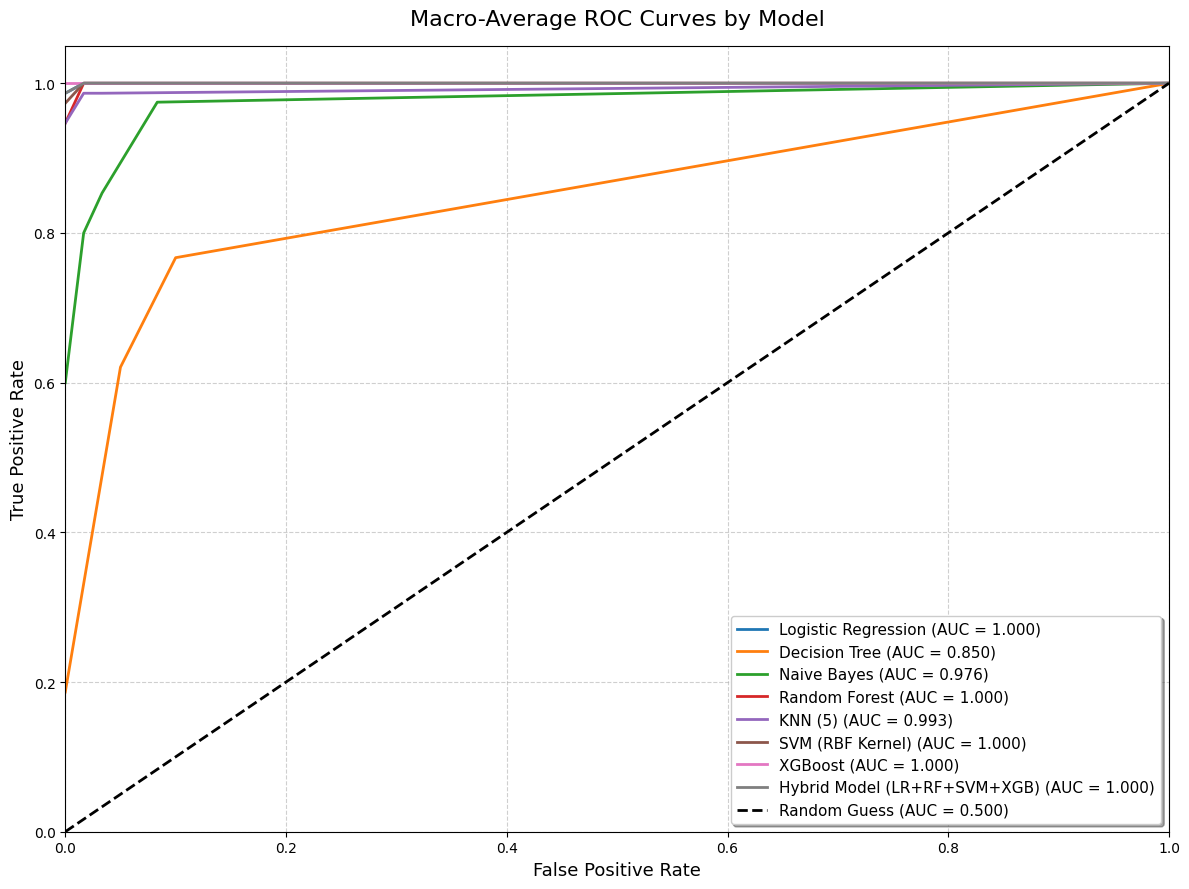

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

print("Generating Multi-Class ROC Curves (Macro-Average) for all models...")

# 1. Binarize the test labels for One-vs-Rest calculation

classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(12, 9))

# 2. Iterate through models to calculate and plot their Macro-ROC
for name, model in models.items():
    # Only process models that can output probabilities
    if hasattr(model, "predict_proba"):
        try:
            # Predict probabilities
            y_prob = model.predict_proba(X_test)
            
            # Dictionaries to store metrics for each class
            fpr = dict()
            tpr = dict()
            
            # Calculate ROC curve for each class individually
            for i in range(n_classes):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
            
            # 3. Calculate Macro-Average ROC
            # Aggregate all unique false positive rates
            all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
            
            # Interpolate all ROC curves at these points
            mean_tpr = np.zeros_like(all_fpr)
            for i in range(n_classes):
                mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
            
            # Average the True Positive Rates
            mean_tpr /= n_classes
            
            # Calculate the final Macro-Average AUC
            macro_auc = auc(all_fpr, mean_tpr)
            
            # 4. Plot the curve for this specific model
            plt.plot(
                all_fpr, 
                mean_tpr, 
                label=f'{name} (AUC = {macro_auc:.3f})',
                linewidth=2
            )
        except Exception as e:
            # Skips gracefully if a specific model encounters an error with predict_proba
            pass

# Plot the 50% Random Guess line (diagonal dashed line)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Random Guess (AUC = 0.500)')

# Formatting the plot
plt.title('Macro-Average ROC Curves by Model', fontsize=16, pad=15)
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Training Multi-Layer Perceptron (MLP) Neural Network...
✅ MLP Training Complete! Test Accuracy: 97.33%

--- MLP Classification Report ---
              precision    recall  f1-score   support

         cat       1.00      1.00      1.00        15
         cow       0.88      1.00      0.94        15
         dog       1.00      1.00      1.00        15
        lamb       1.00      0.87      0.93        15
       zebra       1.00      1.00      1.00        15

    accuracy                           0.97        75
   macro avg       0.98      0.97      0.97        75
weighted avg       0.98      0.97      0.97        75



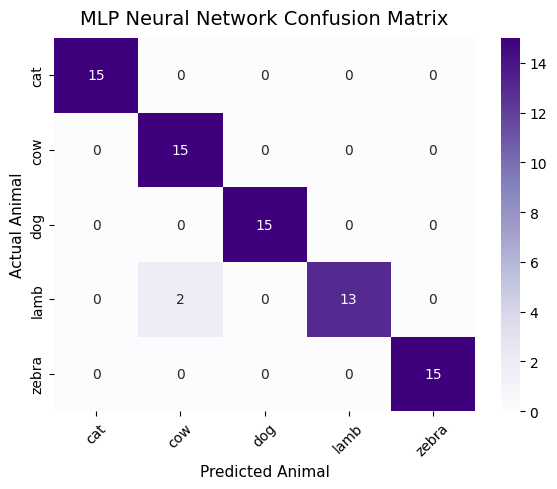

In [14]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Multi-Layer Perceptron (MLP) Neural Network...")

# 1. Initialize the MLP Classifier
# hidden_layer_sizes=(256, 128) means two hidden layers with 256 and 128 neurons respectively.
# max_iter=500 gives it enough epochs to converge without stopping prematurely.
mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128), 
    activation='relu', 
    solver='adam', 
    max_iter=500, 
    random_state=42
)

# 2. Train the model
mlp_model.fit(X_train, y_train)

# 3. Predict on unseen Test Data
y_pred_mlp = mlp_model.predict(X_test)

# 4. Calculate and print metrics
mlp_acc = accuracy_score(y_test, y_pred_mlp)
print(f"✅ MLP Training Complete! Test Accuracy: {mlp_acc * 100:.2f}%\n")
print("--- MLP Classification Report ---")
print(classification_report(y_test, y_pred_mlp, target_names=class_names))

# 5. Add MLP to our master models dictionary for future comparisons
models["MLP Neural Network"] = mlp_model

# 6. Visualize the MLP Confusion Matrix
plt.figure(figsize=(6, 5))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(
    cm_mlp, 
    annot=True, 
    fmt='d', 
    cmap='Purples', # Using purple to distinguish it from the previous blue matrices
    xticklabels=class_names, 
    yticklabels=class_names
)

plt.title('MLP Neural Network Confusion Matrix', fontsize=14, pad=10)
plt.ylabel('Actual Animal', fontsize=11)
plt.xlabel('Predicted Animal', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()